In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Load the dataset**

In [83]:
df = pd.read_excel('/content/R23_R24_structured.xlsx')

In [84]:
df.head()

,Htno,Subcode,Subject,Internals,Grade,Credits
0,319,23MC1A0101,R2331011 DESIGN AND DRAWING OF REINFORCED CONCRET,22,E,3
1,320,23MC1A0101,R2331012 ENGINEERING HYDROLOGY,21,E,3
2,321,23MC1A0101,R2331013 GEOTECHNICAL ENGINEERING-I,21,F,0
3,322,23MC1A0101,R2331014 GEOTECHNICAL ENGINEERING LAB,26,S,1.5
4,323,23MC1A0101,R2331015 FLUID MECHANICS & HYDRAULIC MACHINES LAB,25,A,1.5


**Clean the Data**

In [85]:
df = df.drop(columns = ['Htno'])

In [22]:
df.head()

,Subcode,Subject,Internals,Grade,Credits
0,23MC1A0101,R2331011 DESIGN AND DRAWING OF REINFORCED CONCRET,22,E,3
1,23MC1A0101,R2331012 ENGINEERING HYDROLOGY,21,E,3
2,23MC1A0101,R2331013 GEOTECHNICAL ENGINEERING-I,21,F,0
3,23MC1A0101,R2331014 GEOTECHNICAL ENGINEERING LAB,26,S,1.5
4,23MC1A0101,R2331015 FLUID MECHANICS & HYDRAULIC MACHINES LAB,25,A,1.5


In [86]:
df = df.rename(columns = {'Subcode':'Htno'})

In [87]:
df.head()

,Htno,Subject,Internals,Grade,Credits
0,23MC1A0101,R2331011 DESIGN AND DRAWING OF REINFORCED CONCRET,22,E,3
1,23MC1A0101,R2331012 ENGINEERING HYDROLOGY,21,E,3
2,23MC1A0101,R2331013 GEOTECHNICAL ENGINEERING-I,21,F,0
3,23MC1A0101,R2331014 GEOTECHNICAL ENGINEERING LAB,26,S,1.5
4,23MC1A0101,R2331015 FLUID MECHANICS & HYDRAULIC MACHINES LAB,25,A,1.5


In [88]:
df.to_csv('cleaned_data.csv',index = False)

In [89]:
df.head()

,Htno,Subject,Internals,Grade,Credits
0,23MC1A0101,R2331011 DESIGN AND DRAWING OF REINFORCED CONCRET,22,E,3
1,23MC1A0101,R2331012 ENGINEERING HYDROLOGY,21,E,3
2,23MC1A0101,R2331013 GEOTECHNICAL ENGINEERING-I,21,F,0
3,23MC1A0101,R2331014 GEOTECHNICAL ENGINEERING LAB,26,S,1.5
4,23MC1A0101,R2331015 FLUID MECHANICS & HYDRAULIC MACHINES LAB,25,A,1.5


In [90]:
# Convert Internals and Credits to numeric numbers (ignores text like 'COMPLE' by turning them into NaN)
df['Internals'] = pd.to_numeric(df['Internals'], errors='coerce')

In [91]:
df['Credits'] = pd.to_numeric(df['Credits'], errors='coerce')

In [92]:
df

,Htno,Subject,Internals,Grade,Credits
0,23MC1A0101,R2331011 DESIGN AND DRAWING OF REINFORCED CONCRET,22.0,E,3.0
1,23MC1A0101,R2331012 ENGINEERING HYDROLOGY,21.0,E,3.0
2,23MC1A0101,R2331013 GEOTECHNICAL ENGINEERING-I,21.0,F,0.0
3,23MC1A0101,R2331014 GEOTECHNICAL ENGINEERING LAB,26.0,S,1.5
4,23MC1A0101,R2331015 FLUID MECHANICS & HYDRAULIC MACHINES LAB,25.0,A,1.5
...,...,...,...,...,...
12231,24MC5A6104,R2321054 OBJECT ORIENTED PROGRAMMING THROUGH JAVA,21.0,B,3.0
12232,24MC5A6104,R2321055 ADVANCED DATA STRUCTURES AND ALGORITHMS,25.0,S,1.5
12233,24MC5A6104,R2321056 OBJECT ORIENTED PROGRAMMING THROUGH JAVA,28.0,S,1.5
12234,24MC5A6104,R2321057 PYTHON PROGRAMMING LAB,30.0,S,2.0


In [93]:
# Define passing grades
pass_grades = ['S', 'A', 'B', 'C', 'D', 'E']

In [94]:
# Define grade points for GPA calculation
grade_points = {'S': 10, 'A+': 10, 'A': 9, 'B': 8, 'C': 7, 'D': 6, 'E': 5, 'F': 0, 'ABSENT': 0}
df['Grade_Point'] = df['Grade'].map(grade_points)
print("Data loaded successfully!\n")

Data loaded successfully!



**Student-Level Performance Analysis**

A. GPA / Credit Calculation

In [95]:
# Only count credits for passed subjects
df['Earned_Credits'] = df.apply(lambda row: row['Credits'] if row['Grade'] in pass_grades else 0, axis=1)

In [96]:
# Calculate Total Credits and Total Grade Points per student
df['Total_Points'] = df['Earned_Credits'] * df['Grade_Point']

GPA = Total_Points  /   Total_Earned_Credits

In [97]:
student_gpa = df.groupby('Htno').agg(
    Total_Earned_Credits=('Earned_Credits', 'sum'),
    Total_Points=('Total_Points', 'sum')
).reset_index()

In [98]:
# GPA = Total Points / Total Earned Credits (Avoid division by zero)
student_gpa['Estimated_GPA'] = student_gpa['Total_Points'] / student_gpa['Total_Earned_Credits'].replace(0, 1)
print("Top 5 Students by GPA:")
print(student_gpa.sort_values(by='Estimated_GPA', ascending=False).head(5))

Top 5 Students by GPA:
           Htno  Total_Earned_Credits  Total_Points  Estimated_GPA
458  24MC5A0410                   8.0          78.5       9.812500
3    23MC1A0105                  12.0         116.0       9.666667
212  23MC1A05D6                  12.0         108.0       9.000000
157  23MC1A0577                  64.0         571.5       8.929688
339  23MC1A6148                  20.0         178.5       8.925000


B. Top Performers & At-Risk Students

In [99]:
# Count S/A grades vs F/ABSENT grades per student
top_grades_count = df[df['Grade'].isin(['S', 'A+', 'A'])].groupby('Htno').size()

In [100]:
risk_grades_count = df[df['Grade'].isin(['F', 'ABSENT'])].groupby('Htno').size()

In [101]:
print("\nTop 5 Students (Most S/A Grades):")
print(top_grades_count.sort_values(ascending=False).head(5))


Top 5 Students (Most S/A Grades):
Htno
23MC1A0577    19
23MC1A0420    17
23MC1A6109    17
23MC1A0562    17
24MC5A0405    17
dtype: int64


In [102]:
print("\nTop 5 At-Risk Students (Most F/ABSENT Grades):")
print(risk_grades_count.sort_values(ascending=False).head(5))


Top 5 At-Risk Students (Most F/ABSENT Grades):
Htno
24MC5A4405    27
24MC5A0205    27
23MC1A4442    27
24MC5A0512    27
23MC1A4457    24
dtype: int64


**Subject & Course Analysis**

A. Subject Difficulty (Pass/Fail Rates)

In [103]:
# Check if a student passed or failed
df['Passed'] = df['Grade'].isin(pass_grades)
subject_pass_rates = df.groupby('Subject')['Passed'].mean() * 100 # percentage

In [104]:
print("Top 5 Hardest Subjects (Lowest Pass Rates):")
print(subject_pass_rates.sort_values().head(5))

Top 5 Hardest Subjects (Lowest Pass Rates):
Subject
ENGINEERING PHYSICS ---                              0.0
R2021012 STRENGTH OF MATERIALS-I                     0.0
R2021034 KINEMATICS OF MACHINERY                     0.0
R2021044 RANDOM VARIABLES AND STOCHASTIC PROCESSE    0.0
R2031044 ANALOG ICS AND APPLICATIONS LAB             0.0
Name: Passed, dtype: float64


B. Most Popular Subjects (Highest Enrollments)

In [105]:
subject_enrollments = df['Subject'].value_counts()
print("\nTop 5 Most Enrolled Subjects:")
print(subject_enrollments.head(5))


Top 5 Most Enrolled Subjects:
Subject
R2321012 UNIVERSAL HUMAN VALUES-UNDERSTANDING HAR    426
R2321019 ENVIRONMENTAL SCIENCE(NON CREDITS SUBJEC    419
R2322019 DESIGN THINKING & INNOVATION                419
R233101G ENTREPRENEURSHIP DEVELOPMENT & VENTURE C    356
R2321051 DISCRETE MATHEMATICS & GRAPH THEORY         332
Name: count, dtype: int64


 **Internal Marks Analysis**

A. Internals vs Final Grade

In [106]:
# Average internal marks for each final grade
internals_by_grade = df.groupby('Grade')['Internals'].mean().sort_values(ascending=False)

In [44]:
print("Average Internal Marks by Final Grade:")
print(internals_by_grade)

Average Internal Marks by Final Grade:
Grade
COMPLE    25.857143
S         24.872000
A         22.778910
C         20.117589
B         19.647170
D         18.951303
E         15.654284
F         14.506914
MP        14.500000
ABSENT    14.020376
A+         0.000000
CO              NaN
Change          NaN
Name: Internals, dtype: float64


B. Internal Scoring Patterns

In [107]:
# Which subjects give the highest/lowest average internals?
subject_avg_internals = df.groupby('Subject')['Internals'].mean().dropna()

In [108]:
print("\nTop 5 Subjects with HIGHEST Average Internals:")
print(subject_avg_internals.sort_values(ascending=False).head(5))


Top 5 Subjects with HIGHEST Average Internals:
Subject
R2322017 ENGINEERING GEOLOGYLAB                      28.000000
R2322016 CONCRETE TECHNOLOGY LAB                     27.750000
R2321017 STRENGTH OF MATERIALS LAB                   27.571429
R2331047 DESIGN OF PCB & ANTENNAS LAB                27.333333
R2322018 REMOTE SENSING & GEOGRAPHICAL INFORMATIO    27.125000
Name: Internals, dtype: float64


**Overall Institutional Trends (Visualizations)**

In [109]:
plt.figure(figsize=(15, 5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

A. Overall Grade Distribution

/tmp/ipykernel_1146/876696822.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade_counts.index, y=grade_counts.values, palette='viridis')


Text(0, 0.5, 'Number of Students')

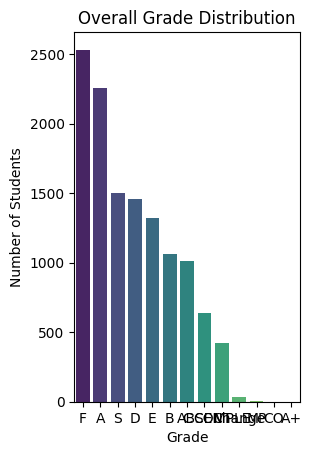

In [110]:
plt.subplot(1, 2, 1)
grade_counts = df['Grade'].value_counts()
sns.barplot(x=grade_counts.index, y=grade_counts.values, palette='viridis')
plt.title('Overall Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Number of Students')

B. Attendance Issues (Top 10 Subjects with most ABSENTs)

/tmp/ipykernel_1146/2693153979.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=absent_counts.index, x=absent_counts.values, palette='magma')


Text(0, 0.5, 'Subject')

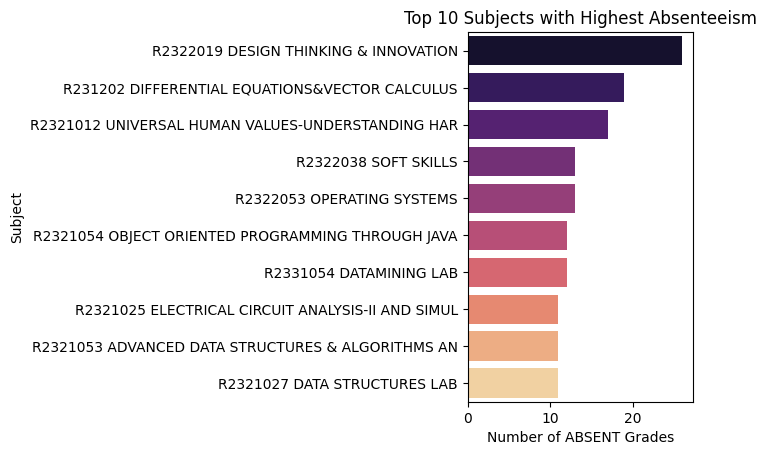

In [111]:
plt.subplot(1, 2, 2)
absent_df = df[df['Grade'] == 'ABSENT']
absent_counts = absent_df['Subject'].value_counts().head(10)
sns.barplot(y=absent_counts.index, x=absent_counts.values, palette='magma')
plt.title('Top 10 Subjects with Highest Absenteeism')
plt.xlabel('Number of ABSENT Grades')
plt.ylabel('Subject')
# plt.tight_layout()
# plt.show

**Import ML Libraries**

In [112]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

**Prepare Features and Target**

In [113]:
# Create the target variable: 1 if passed, 0 if failed
df['Pass_Fail'] = df['Grade'].isin(pass_grades).astype(int)


In [114]:
# Select inputs (X) and output (y)
X = df[['Internals', 'Credits']].fillna(0) # Fill empty internals with 0
y = df['Pass_Fail']

**Split Data into Train and Test Sets**

In [115]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=26)

**Train the Model**

*Random Forest Classifier*. It is highly effective for student data because it handles different types of patterns well.

In [116]:
# Initialize and train the 'brain'
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

**Make Predictions and Evaluate**

In [117]:
y_pred = model.predict(X_test)

In [135]:
y_pred

array([1, 1, 0, ..., 1, 1, 0])

In [118]:
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 99.96%

Detailed Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       707
           1       1.00      1.00      1.00      1741

    accuracy                           1.00      2448
   macro avg       1.00      1.00      1.00      2448
weighted avg       1.00      1.00      1.00      2448



**Predict for a New Student**

to predict the fate of a new student based on their current internal marks.

In [119]:
# Example: Student has 15 internal marks in a 4-credit course
new_student = [[15, 4]]
prediction = model.predict(new_student)
result = "Pass" if prediction[0] == 1 else "Fail"
print(f"Prediction for new student: {result}")


Prediction for new student: Pass


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [134]:
prediction

array([1])

In [120]:
import matplotlib.pyplot as plt
from sklearn import tree

In [121]:
from sklearn.tree import DecisionTreeClassifier

In [122]:
dtree = DecisionTreeClassifier(max_depth=3, random_state=42)
dtree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

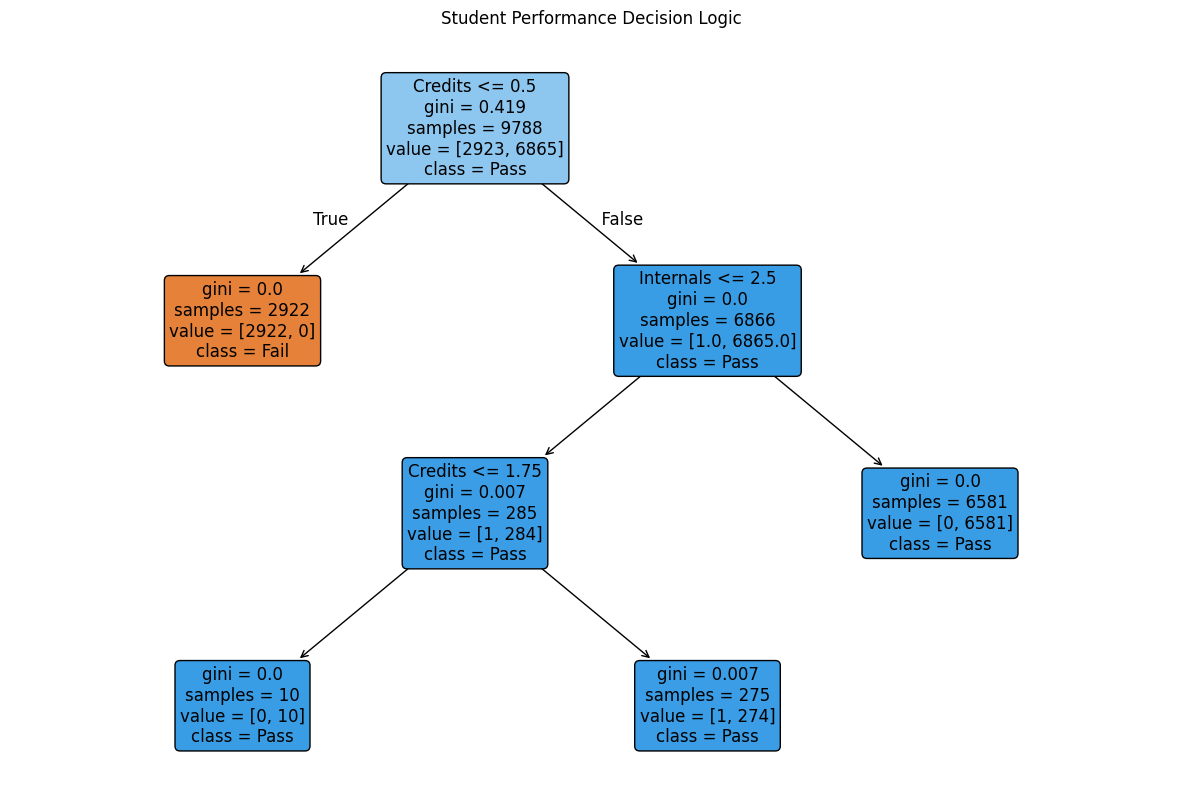

In [123]:
plt.figure(figsize=(15, 10))
tree.plot_tree(dtree,
               feature_names=['Internals', 'Credits'],  # The inputs
               class_names=['Fail', 'Pass'],            # The outcomes
               filled=True,                             # Colours the nodes
               rounded=True,                            # Rounded boxes
               fontsize=12)

plt.title("Student Performance Decision Logic")
plt.show()

In [124]:
# 1. Calculate the correlation score
correlation_score = df['Internals'].corr(df['Grade_Point'])

print(f"Correlation between Internals and Grade Point: {correlation_score:.2f}")

# 2. Interpret the result
if correlation_score > 0.7:
    print("Trend: Strong relationship! Internals are a great predictor of success.")
elif correlation_score > 0.4:
    print("Trend: Moderate relationship. Other factors (like the final exam) matter too.")
else:
    print("Trend: Weak relationship. Students' final grades vary regardless of internals.")


Correlation between Internals and Grade Point: 0.52
Trend: Moderate relationship. Other factors (like the final exam) matter too.


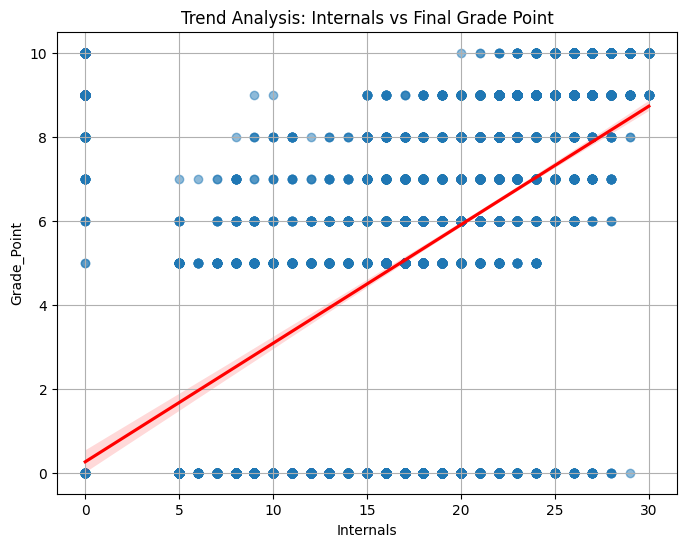

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.regplot(x='Internals', y='Grade_Point', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Trend Analysis: Internals vs Final Grade Point')
plt.grid(True)
plt.show()


**XGBoost (Extreme Gradient Boosting)**

To apply the XGBoost (Extreme Gradient Boosting) algorithm to your student data

In [126]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [127]:
# Define Features (X) and Target (y)
X = df[['Internals', 'Credits']].fillna(0)
y = df['Grade'].isin(pass_grades).astype(int) # 1 for Pass, 0 for Fail

In [128]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [129]:
#  Create the model
# n_estimators: number of trees to build
# max_depth: how deep each tree can grow
# learning_rate (eta): how much each tree corrects the previous one
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [130]:
# Train the model
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:09:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [131]:
y_pred = xgb_model.predict(X_test)

In [132]:
y_pred

array([1, 1, 0, ..., 1, 1, 0])

In [133]:
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Model Accuracy: {accuracy * 100:.2f}%")

XGBoost Model Accuracy: 100.00%


In [137]:
from google.colab import files
df.to_csv('Student_Results.csv', index=False) # Save the dataframe to the desired file name
files.download('Student_Results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [141]:
from google.colab import files
files.download('grade_distribution.png')
files.download('decision_tree_logic.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_1146/175096115.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Grade', data=df, order=order, palette='viridis')


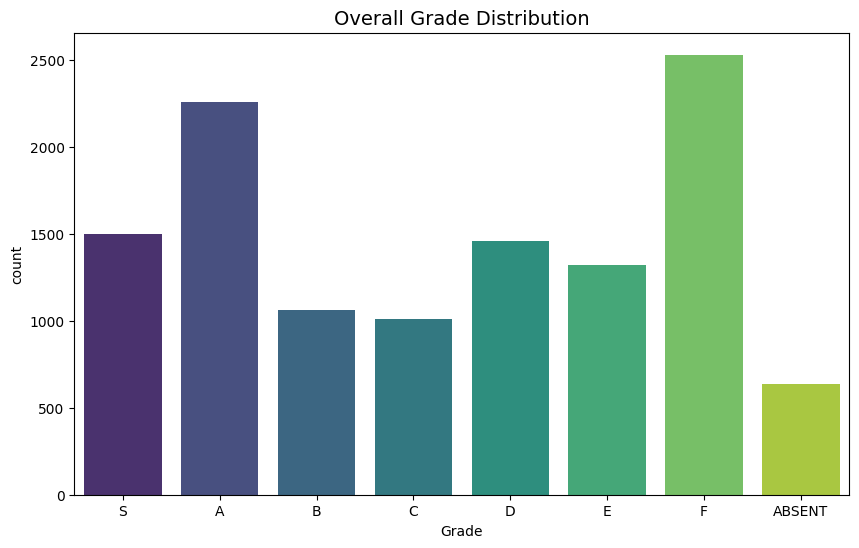

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your main dataframe
plt.figure(figsize=(10, 6))
order = ['S','A', 'B', 'C', 'D', 'E', 'F', 'ABSENT']
sns.countplot(x='Grade', data=df, order=order, palette='viridis')

plt.title('Overall Grade Distribution', fontsize=14)
# Save as a high-quality PNG
plt.savefig('grade_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


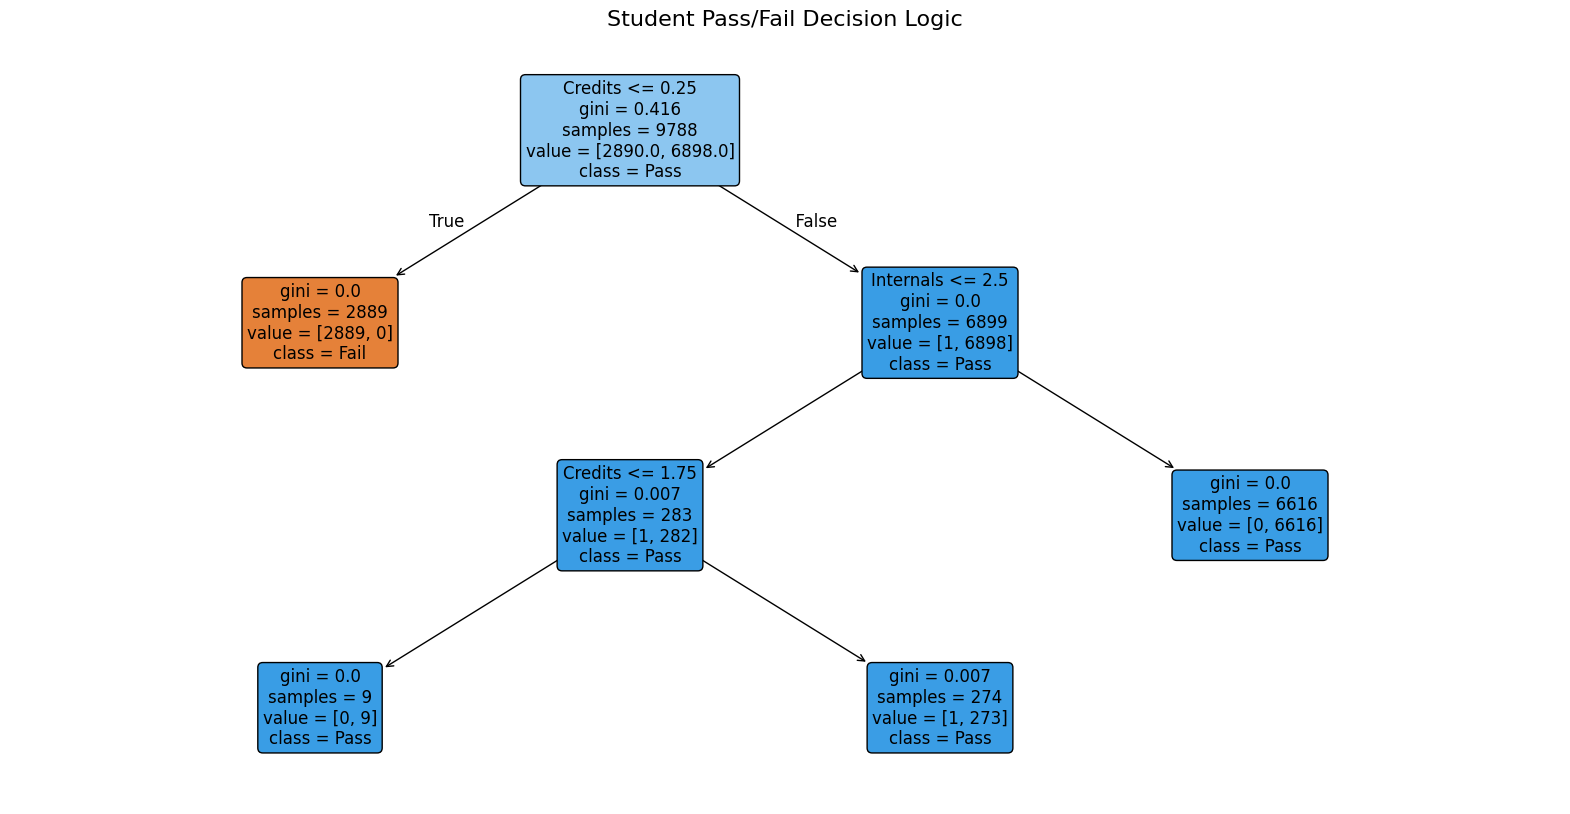

In [139]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Training a simple tree for visualization (max_depth=3 keeps it readable)
dtree = DecisionTreeClassifier(max_depth=3, random_state=42)
dtree.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dtree,
          feature_names=['Internals', 'Credits'],
          class_names=['Fail', 'Pass'],
          filled=True,
          rounded=True,
          fontsize=12)

plt.title('Student Pass/Fail Decision Logic', fontsize=16)
# Save the flowchart
plt.savefig('decision_tree_logic.png', dpi=300, bbox_inches='tight')
plt.show()
